In [23]:
#importing libraries for data anaylsis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
#loading the unigram frequency data set
df=pd.read_csv('/content/unigram_freq.csv')
print(df.shape)
df.head(1000)

(333333, 2)


,word,count
0,the,23135851162
1,of,13151942776
2,and,12997637966
3,to,12136980858
4,a,9081174698
...,...,...
995,japan,81110725
996,doing,80821946
997,loans,80821333
998,shoes,80755612


In [25]:
#now exploring basic information about dataset
print("Total uniique words:",len(df))

print("\nTop 10 most frequently used words:")

print(df.head(10))

Total uniique words: 333333

Top 10 most frequently used words:
   word        count
0   the  23135851162
1    of  13151942776
2   and  12997637966
3    to  12136980858
4     a   9081174698
5    in   8469404971
6   for   5933321709
7    is   4705743816
8    on   3750423199
9  that   3400031103


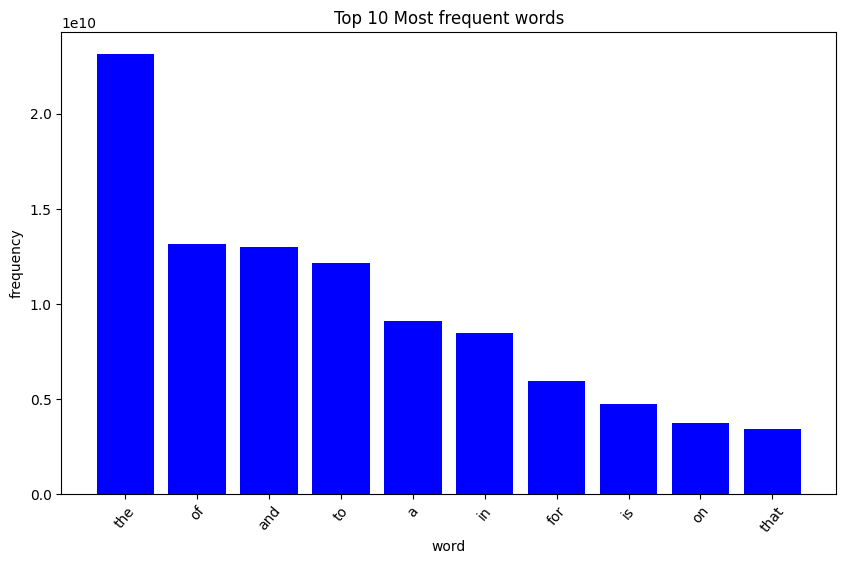

In [53]:
#now visualizing the top 25 most common words in english langauge

top10=df.head(10)
plt.figure(figsize=(10,6))
plt.bar(top10['word'],top10['count'],color='blue')
plt.title('Top 10 Most frequent words')
plt.xlabel('word')
plt.ylabel('frequency')
plt.xticks(rotation=50)
plt.show()


In [54]:
# autocomplete function - suggests words based on starting prefix
# words are sorted by frequency so most common words appear first
def autocomplete(prefix, n=5):
    matches = df[df['word'].fillna('').str.startswith(prefix)]
    matches = matches.sort_values('count', ascending=False)
    return matches['word'].head(n).tolist()



In [55]:

# testing autocomplete with different prefixes
print("Suggestions for 'pro':", autocomplete('pro'))
print("Suggestions for 'the':", autocomplete('the'))
print("Suggestions for 'com':", autocomplete('com'))

Suggestions for 'pro': ['products', 'product', 'program', 'project', 'profile']
Suggestions for 'the': ['the', 'they', 'their', 'there', 'these']
Suggestions for 'com': ['company', 'comments', 'community', 'computer', 'compare']


#autocorrect function
#filters words by similar length first to reduce space


In [56]:

def autocorrect(wrong_word): # creating the function


    word_len = len(wrong_word) # find the length of the worng word

    similar_len_words = df[
        df['word'].str.len().between(word_len-1, word_len+1)
    ].head(1000)['word'].tolist() #Converting all words from the dataset into Python list so we can search

    from difflib import get_close_matches #Importing a built-in Python tool
    matches = get_close_matches(wrong_word, similar_len_words, n=1, cutoff=0.6) #et_close_matches compares your wrong word against allwords and finds the most similar one
    return matches[0] if matches else "no correction found" #If a match was found- return it.



# test
print(autocorrect('speling'))
print(autocorrect('recieve'))
print(autocorrect('langauge'))

selling
receive
language


In [57]:
# comparing autocomplete results for multiple prefixes
prefixes = ['th','wh','pr','co']
for p in prefixes:
  Suggestions = autocomplete(p,3)
  print(f"Suggestions for '{p}': {Suggestions}")


Suggestions for 'th': ['the', 'that', 'this']
Suggestions for 'wh': ['what', 'which', 'when']
Suggestions for 'pr': ['price', 'products', 'product']
Suggestions for 'co': ['contact', 'copyright', 'company']


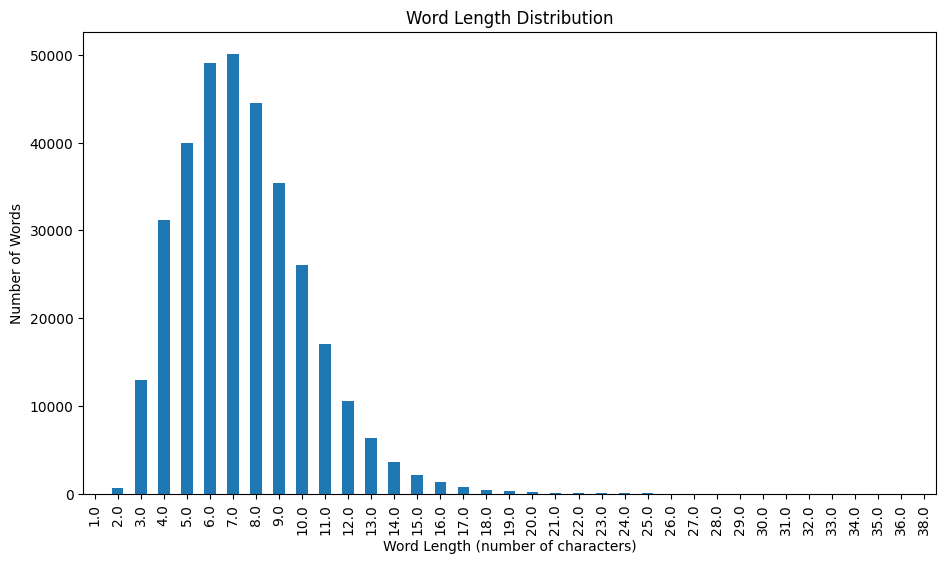

In [58]:
#analyzing  word length in the dataset
df['word_length'] = df['word'].str.len() # creating the new column that will stores of each word
plt.figure(figsize=(11,6)) # plotting distribution
df['word_length'].value_counts().sort_index().plot(kind='bar')
plt.title('Word Length Distribution')
plt.xlabel('Word Length (number of characters)')
plt.ylabel('Number of Words')
plt.show()



#Autocomplete and Autocorrect Analysis

#Dataset
- English words with frequency counts
- Source: English Unigram Frequency dataset

#Autocomplete
- Suggests top words matching a given prefix
- Sorted by frequency for most relevant suggestions
- Example: 'pro' → ['professional', 'program', 'provide' . 'proactive','proportion']

# Autocorrect
- Uses difflib to find closest matching word
- Corrects common spelling mistakes
- Example: 'speling' to 'spelling'

# Key Insights
- Short words like 'the', 'of', 'and' dominate frequency
- Most words are 5-8 characters long
- Frequency based autocomplete gives more relevant results

#Tools Used
Python, Pandas, Difflib, Matplotlib, Seaborn